In [6]:
library(Seurat)
#library(SeuratData)
library(patchwork)
library(ggplot2)
library(purrr)
library(dplyr)
library(stringr)
library(ggpubr)
library(pheatmap)
library( RColorBrewer)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [7]:
library(ggplot2)

In [8]:
GCA_obj_subset <- readRDS(file = "GCA_obj_subset_celltype.Rdata")

### load the group

In [9]:
ERBB2_group <- read.table('ERBB2_7.txt',header=T)

In [22]:
ERBB2_group

,ERBB2
,<dbl>
SC008,0.805233
SC005,2.314381
SC027,3.860049
SC032,7.478490
SC017,7.827742
SC015,8.709902
SC031,9.204221


In [23]:
GCA_obj_subset@meta.data[,c("orig.ident","nCount_RNA","nFeature_RNA","sample","percent.mt",
                            "RNA_snn_res.1.2","seurat_clusters","Maincelltype","subcelltype")] ->GCA_obj_subset@meta.data

In [24]:
GCA_obj_subset@meta.data -> metadata

In [25]:
metadata %>% count(sample,subcelltype) -> sample_subcelltype_number

In [26]:
head(sample_subcelltype_number)

,sample,subcelltype,n
,<chr>,<chr>,<int>
1,SC005,Bcell,227
2,SC005,Endothelial,151
3,SC005,Epi_normal,24
4,SC005,Epi_tumor,709
5,SC005,Fabroblasts,145
6,SC005,Mastcell,84


### for bar plot

In [27]:
sample_subcelltype_number %>% group_by(sample) %>% 
    reframe(Percentage = n/sum(n),celltype = subcelltype)%>% as.data.frame() -> sample_subcelltype_number2

In [28]:
sample_subcelltype_number2$sample %>% unique()

[1] "SC005" "SC008" "SC015" "SC017" "SC027" "SC031" "SC032"

In [29]:
sample_subcelltype_number2$sample <-  factor(sample_subcelltype_number2$sample,levels = rownames(ERBB2_group))

In [33]:
sample_subcelltype_number2

sample,Percentage,celltype
<fct>,<dbl>,<chr>
SC005,0.0391176977,Bcell
SC005,0.0260210236,Endothelial
SC005,0.0041357918,Epi_normal
SC005,0.1221781837,Epi_tumor
SC005,0.0249870757,Fabroblasts
SC005,0.0144752714,Mastcell
SC005,0.0056867138,Musclecell
SC005,0.2057556436,MyeloidCells
SC005,0.0093055316,Pericyte


In [34]:
options(repr.plot.height=6,repr.plot.width=8)
p_dis <- ggplot(sample_subcelltype_number2, aes(fill=celltype, y=Percentage, x=sample)) + theme_bw()+
    theme(axis.text.x = element_text(angle=45,hjust=1,color='black'))+
    geom_bar(position="stack", stat="identity")

In [35]:
#p_dis <- p_dis+ scale_fill_manual(values = colorRampPalette(brewer.pal(5, "Spectral"))(9))

In [ ]:
options(repr.plot.height=6,repr.plot.width=8)
p_dis

In [ ]:
ggsave(filename = "All_celltype_distribution.pdf",plot = p_dis,height = 6,width = 8)

### for heatmap

In [37]:
sample_subcelltype_number2 %>% tidyr::pivot_wider(names_from = c(sample), values_from = Percentage) %>% as.data.frame() -> sample_subcelltype_number2_forheatmap

In [38]:
rownames(sample_subcelltype_number2_forheatmap) <- sample_subcelltype_number2_forheatmap$celltype

In [39]:
sample_subcelltype_number2_forheatmap <- sample_subcelltype_number2_forheatmap[,2:ncol(sample_subcelltype_number2_forheatmap)]

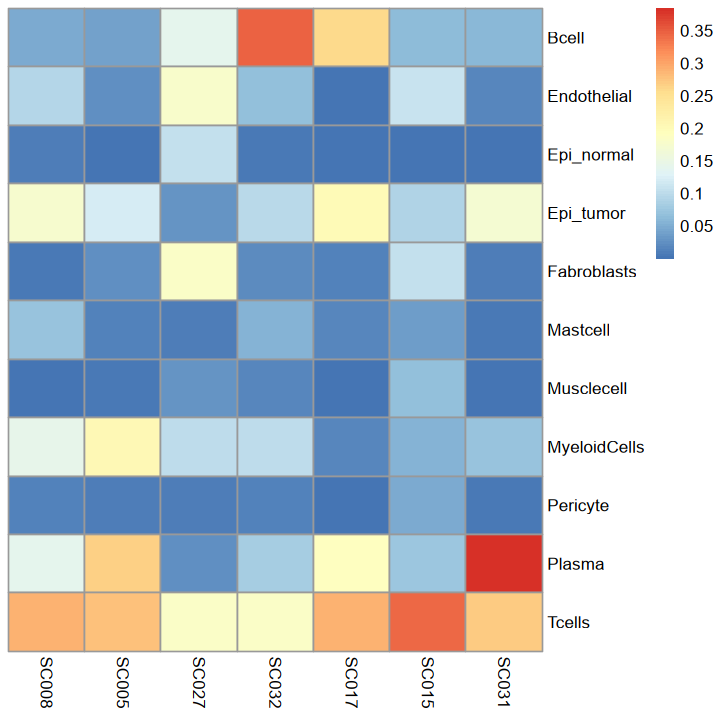

In [41]:
options(repr.plot.height=6,repr.plot.width=6)
pheatmap(sample_subcelltype_number2_forheatmap[,rownames(ERBB2_group)],cluster_rows = F,cluster_cols = F,
         #width = 6,height = 6,filename = "All_celltype_distribution.heatmap.pdf" 
        )

### boxplot

In [66]:
ERBB2_group$sample <- rownames(ERBB2_group)

In [67]:
ERBB2_group

,ERBB2,sample
,<dbl>,<chr>
SC008,0.805233,SC008
SC005,2.314381,SC005
SC027,3.860049,SC027
SC032,7.478490,SC032
SC017,7.827742,SC017
SC015,8.709902,SC015
SC031,9.204221,SC031


In [68]:
ERBB2_group$sample <- factor(ERBB2_group$sample,levels = ERBB2_group$sample)

In [69]:
options(repr.plot.height=4,repr.plot.width=4)
p_erbb2_group <- ggplot(data =ERBB2_group )+geom_point(aes(x=sample,y=ERBB2))+theme_bw()+
    theme(panel.grid = element_blank())+theme(axis.text.x = element_text(color='black',angle=45,hjust = 1))+
    theme(axis.text.y = element_text(color='black'))+xlab("") +ylab("TPM of ERBB2")

In [80]:
saveRDS(ERBB2_group,file = '/disk1/pengweixing/esophageal/30.sourcedata/Figure5e.Rds')

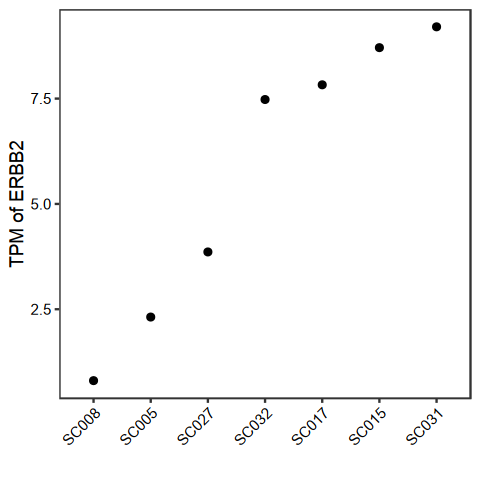

In [48]:
p_erbb2_group

In [ ]:
ggsave(filename = "ERBB2_groupbyTPM.pdf",plot =p_erbb2_group,width = 4,height = 4)

In [73]:
ERBB2_group

,ERBB2,sample
,<dbl>,<fct>
SC008,0.805233,SC008
SC005,2.314381,SC005
SC027,3.860049,SC027
SC032,7.478490,SC032
SC017,7.827742,SC017
SC015,8.709902,SC015
SC031,9.204221,SC031


In [71]:
sample_subcelltype_number2

sample,Percentage,celltype
<fct>,<dbl>,<chr>
SC005,0.0391176977,Bcell
SC005,0.0260210236,Endothelial
SC005,0.0041357918,Epi_normal
SC005,0.1221781837,Epi_tumor
SC005,0.0249870757,Fabroblasts
SC005,0.0144752714,Mastcell
SC005,0.0056867138,Musclecell
SC005,0.2057556436,MyeloidCells
SC005,0.0093055316,Pericyte


In [74]:
library(dplyr)

sample_subcelltype_number2 <- sample_subcelltype_number2 %>%
  left_join(ERBB2_group, by = "sample")

In [75]:
sample_subcelltype_number2

sample,Percentage,celltype,ERBB2
<fct>,<dbl>,<chr>,<dbl>
SC005,0.0391176977,Bcell,2.314381
SC005,0.0260210236,Endothelial,2.314381
SC005,0.0041357918,Epi_normal,2.314381
SC005,0.1221781837,Epi_tumor,2.314381
SC005,0.0249870757,Fabroblasts,2.314381
SC005,0.0144752714,Mastcell,2.314381
SC005,0.0056867138,Musclecell,2.314381
SC005,0.2057556436,MyeloidCells,2.314381
SC005,0.0093055316,Pericyte,2.314381


In [76]:
sample_subcelltype_number2 %>% filter(celltype=="MacrophageM2") %>% arrange(celltype) -> ERBB2_epi

In [77]:
sample_subcelltype_number2 %>% mutate(group = ifelse(ERBB2<7,"Low","High")) -> sample_subcelltype_number2_group

In [78]:
options(repr.plot.height=8,repr.plot.width=8)
p_box <- ggboxplot(sample_subcelltype_number2_group,x="group",y="Percentage",add="jitter",add.params=list(shape=21, fill="orange", size=3)
             )+geom_signif(comparisons = list(c("High","Low")),step_increase = 0.1,map_signif_level = F,
                           test = t.test)+ylab("Proportion") +  scale_y_continuous(expand = expansion(mult = c(0.05, 0.15)))+
                    facet_wrap(~celltype, scale="free")

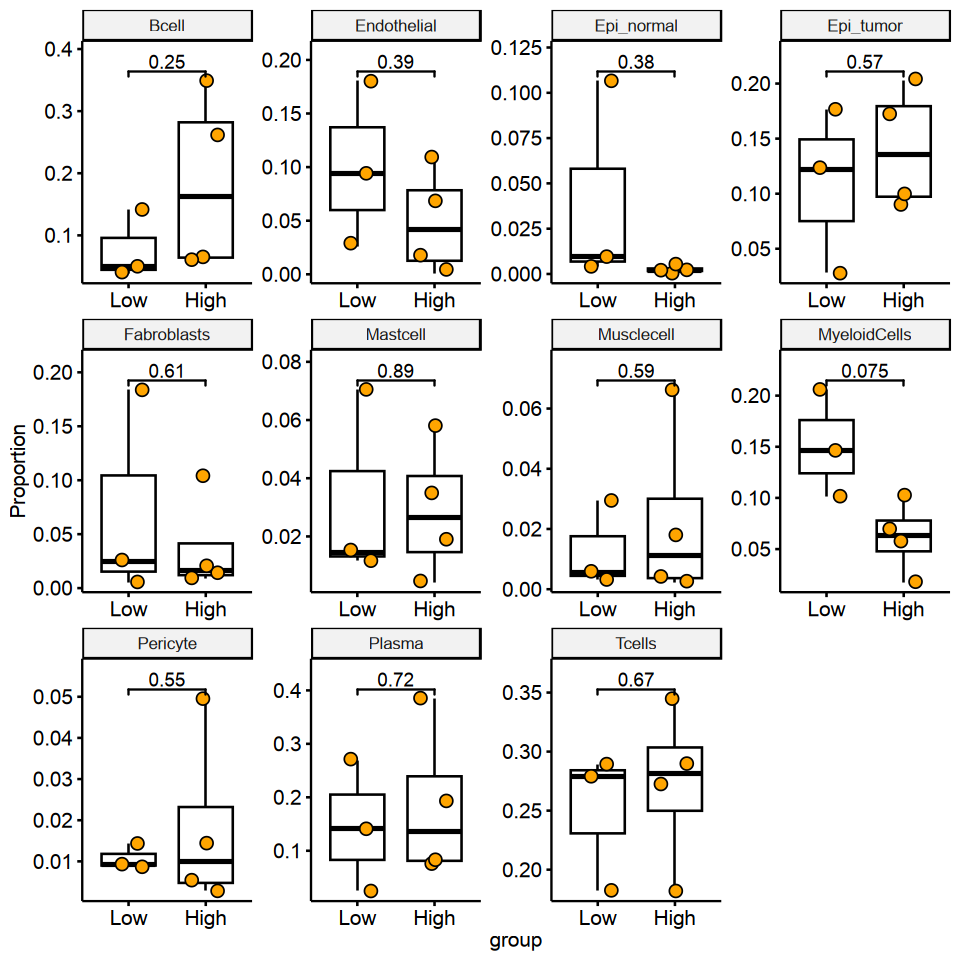

In [79]:
p_box

In [ ]:
ggsave(filename = "Lymphcytes_ERBB2_compare_boxplot.pdf",plot = p_box,height = 8,width = 8)

### group names

In [54]:
ERBB2_group

,ERBB2,sample
,<dbl>,<fct>
SC008,0.805233,SC008
SC005,2.314381,SC005
SC027,3.860049,SC027
SC032,7.478490,SC032
SC017,7.827742,SC017
SC015,8.709902,SC015
SC031,9.204221,SC031


In [55]:
lownames <- c("SC008","SC005","SC027")
highnames <- c("SC032","SC017","SC015","SC031")

In [56]:
save.image('ERBB2_group.Rdata')

In [57]:
GCA_obj_subset[,GCA_obj_subset$sample  %in% lownames] -> GCA_obj_subset_low

In [58]:
GCA_obj_subset[,GCA_obj_subset$sample  %in% highnames] -> GCA_obj_subset_high

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


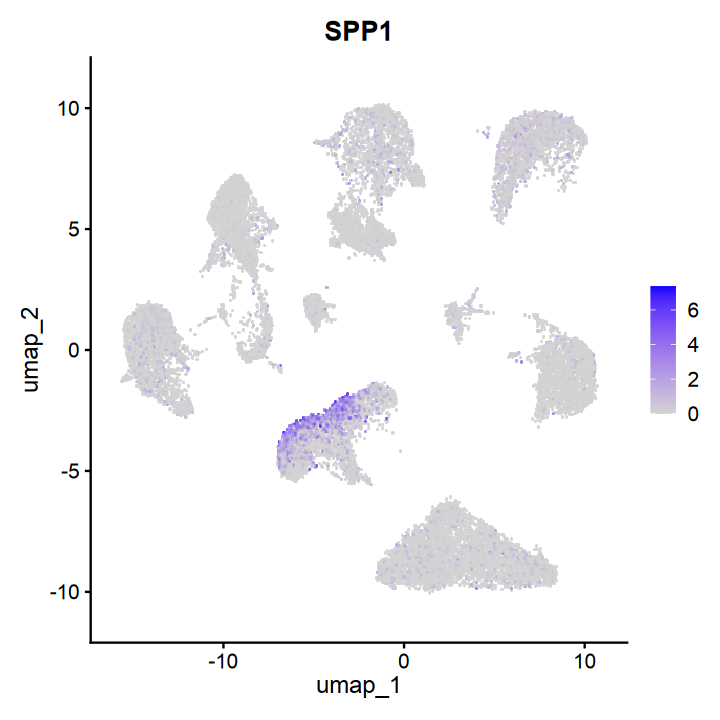

In [59]:
options(repr.plot.height=6,repr.plot.width=6)
FeaturePlot(GCA_obj_subset_low,  features = c("SPP1"), raster = TRUE,pt.size = 2)

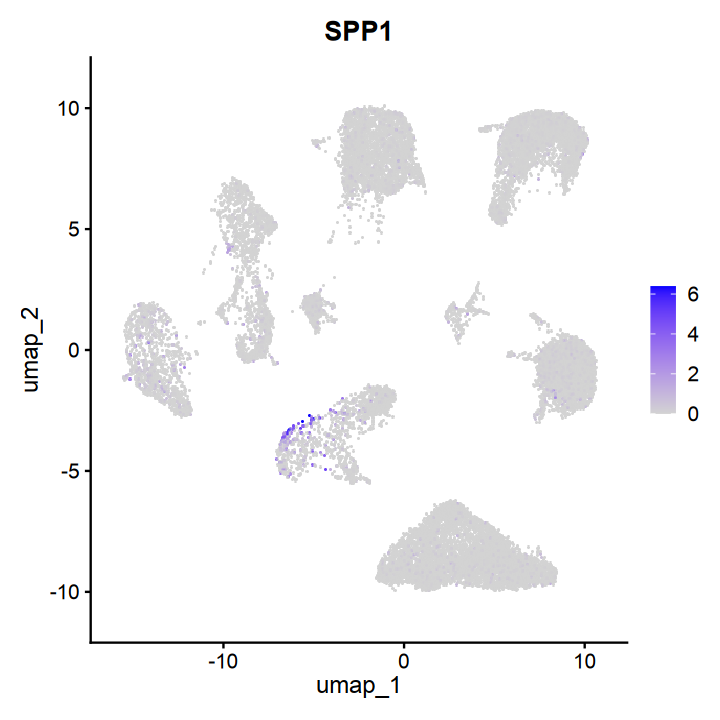

In [60]:
options(repr.plot.height=6,repr.plot.width=6)
FeaturePlot(GCA_obj_subset_high,  features = c("SPP1"),
                          raster = TRUE,pt.size = 2)